In [50]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

df = pd.read_excel('Alunos Graduação até 27-02-2024_ Limpo.xlsx')

df.columns

Index(['Matrícula', 'Nascimento', 'Sexo', 'Situação Matrícula',
       'Último Evento de Matrícula', 'Última Presença',
       'Sit. Últ. Per. Letivo', 'Per. Let. Inigresso', 'Turma Atual',
       'Qtd Períodos', 'Curso', 'Turno Ingresso', 'Período Atual',
       'Naturalidade', 'Renda Familiar', 'Cota', 'Renda Familiar Per Capita',
       'Renda Familiar Per Capita SIG', 'Renda Familiar Per Capita PNP',
       'Escola de Origem', 'Area Procedência Escola Origem', 'Bairro',
       'C.E.P.', 'Cidade', 'Cor/Raça'],
      dtype='object')

In [51]:
colunas_a_remover = ['Sit. Últ. Per. Letivo', 'Turma Atual', 'Qtd Períodos', 'Naturalidade', 'Renda Familiar Per Capita',
       'Renda Familiar Per Capita SIG', 'Renda Familiar Per Capita PNP']
df = df.drop(columns=colunas_a_remover)
df.columns

Index(['Matrícula', 'Nascimento', 'Sexo', 'Situação Matrícula',
       'Último Evento de Matrícula', 'Última Presença', 'Per. Let. Inigresso',
       'Curso', 'Turno Ingresso', 'Período Atual', 'Renda Familiar', 'Cota',
       'Escola de Origem', 'Area Procedência Escola Origem', 'Bairro',
       'C.E.P.', 'Cidade', 'Cor/Raça'],
      dtype='object')

In [52]:
percent_missing = df.isna().mean() * 100
percent_missing

Matrícula                          0.000000
Nascimento                         0.000000
Sexo                               0.000000
Situação Matrícula                 0.000000
Último Evento de Matrícula         0.052274
Última Presença                    0.679561
Per. Let. Inigresso                0.000000
Curso                              0.000000
Turno Ingresso                     0.000000
Período Atual                      0.000000
Renda Familiar                    29.116571
Cota                              39.728176
Escola de Origem                   2.665970
Area Procedência Escola Origem     3.606900
Bairro                             1.725039
C.E.P.                             0.000000
Cidade                             1.150026
Cor/Raça                           0.261370
dtype: float64

In [53]:
df['Escola de Origem'].fillna(df['Escola de Origem'].mode()[0], inplace=True)
df['Area Procedência Escola Origem'].fillna(df['Area Procedência Escola Origem'].mode()[0], inplace=True)
df['Cor/Raça'].fillna(df['Cor/Raça'].mode()[0], inplace=True)
df['Cidade'].fillna(df['Cidade'].mode()[0], inplace=True)
df['Bairro'].fillna(df['Bairro'].mode()[0], inplace=True)
df['Último Evento de Matrícula'].fillna(df['Último Evento de Matrícula'].mode()[0], inplace=True)
df['Última Presença'].fillna(df['Última Presença'].mode()[0], inplace=True)
df = df[df['C.E.P.'] != '-']

df['Ano Evadido'] = pd.to_datetime(df['Último Evento de Matrícula'].str.extract(r'(\d{2}/\d{2}/\d{4})')[0], format='%d/%m/%Y').dt.year

df['Curso'] = df['Curso'].str.title()
df['Sexo'] = df['Sexo'].map({'M': 'Masculino', 'F': 'Feminino'})

proporcao = df['Renda Familiar'].value_counts(normalize=True)

# Criar uma série com base na amostra aleatória dos valores existentes, ponderados pela proporção
valores_amostrados = pd.Series(proporcao).sample(n=df['Renda Familiar'].isna().sum(), replace=True).index

# Preencher os dados faltantes com base na amostra aleatória
df['Renda Familiar'].fillna(pd.Series(valores_amostrados, index=df[df['Renda Familiar'].isna()].index), inplace=True)

percent_missing = df.isna().mean() * 100
percent_missing

C:\Users\Matheus\AppData\Local\Temp\ipykernel_11980\2885990951.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Escola de Origem'].fillna(df['Escola de Origem'].mode()[0], inplace=True)
C:\Users\Matheus\AppData\Local\Temp\ipykernel_11980\2885990951.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

Matrícula                          0.000000
Nascimento                         0.000000
Sexo                               0.000000
Situação Matrícula                 0.000000
Último Evento de Matrícula         0.000000
Última Presença                    0.000000
Per. Let. Inigresso                0.000000
Curso                              0.000000
Turno Ingresso                     0.000000
Período Atual                      0.000000
Renda Familiar                     0.000000
Cota                              39.728176
Escola de Origem                   0.000000
Area Procedência Escola Origem     0.000000
Bairro                             0.000000
C.E.P.                             0.000000
Cidade                             0.000000
Cor/Raça                           0.000000
Ano Evadido                        0.000000
dtype: float64

In [54]:
years = [int(i[:4]) for i in df['Per. Let. Inigresso']]
todos_anos = range(min(years), max(years) + 1)
for ano in todos_anos:
    df[ano] = df.apply(lambda row: int(row['Última Presença'][-4:]) >= ano and int(row['Per. Let. Inigresso'][:4]) <= ano, axis=1)


In [55]:
valores_a_manter = ['Cancelado', 'Cancelado Compulsório', 'Evasão', 'Transferido Externo', 'Transferido Interno']  # Exemplo de valores a serem mantidos
df_evadidos = df[df['Situação Matrícula'].isin(valores_a_manter)]


df_evadidos.shape[0]

547

In [56]:
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
from geopy.extra.rate_limiter import RateLimiter


# Inicialize o geolocalizador
geolocator = Nominatim(user_agent="myGeocoder")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

df_point = pd.DataFrame()
df_aux = df_evadidos[df_evadidos['Curso'] == "Licenciatura Em Matemática"]
df_point['info'] = df_aux['Bairro'] + ', ' + df_aux['Cidade']
df_point['endereço'] = df_point['info'].apply(geocode)


RateLimiter caught an error, retrying (0/2 tries). Called with (*('Ibc, Cachoeiro de Itapemirim - ES',), **{}).
Traceback (most recent call last):
  File "C:\Users\Matheus\AppData\Roaming\Python\Python312\site-packages\geopy\geocoders\base.py", line 368, in _call_geocoder
    result = self.adapter.get_json(url, timeout=timeout, headers=req_headers)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Matheus\AppData\Roaming\Python\Python312\site-packages\geopy\adapters.py", line 472, in get_json
    resp = self._request(url, timeout=timeout, headers=headers)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Matheus\AppData\Roaming\Python\Python312\site-packages\geopy\adapters.py", line 500, in _request
    raise AdapterHTTPError(
geopy.adapters.AdapterHTTPError: Non-successful status code 403

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "C:\Users\

In [57]:
df_work = df_point.dropna()
df_teste = df_work['endereço'].apply(lambda loc: loc if 'Cachoeiro' in loc.raw['display_name'] else None).dropna()
df_teste


76      (Boa Vista do Sul, Marataízes, Região Geográfi...
89      (Alto Novo Parque, Nossa Senhora de Fátima, Ca...
93      (Vila Rica, Cachoeiro de Itapemirim, Região Ge...
100     (ES-488, São Luiz Gonzaga, Cachoeiro de Itapem...
110     (Parque das Laranjeiras, Cachoeiro de Itapemir...
                              ...                        
1866    (Alto Amarelo, Cachoeiro de Itapemirim, Região...
1872    (Rua Doutor José Monteiro da Silva, Pratinha, ...
1880    (Abelardo Ferreira Machado, Cachoeiro de Itape...
1892    (Centro, Muqui, Região Geográfica Imediata de ...
1897    (Waldir Furtado Amorim (BNH de Baixo), Cachoei...
Name: endereço, Length: 167, dtype: object

In [58]:
df_work['point'] = df_work['endereço'].apply(lambda loc: [loc.latitude, loc.longitude] if loc else None)
print(df_work['point'])

import folium
from folium.plugins import HeatMap

coords = [cord for cord in df_work['point'] if cord and cord[0] and cord[1]]
map = folium.Map(location = [-20.8280, -41.1273], zoom_start = 10, control_scale= True, tiles = "cartodbpositron")

for point in coords:
    folium.Marker(location=point).add_to(map)

map.add_child(folium.LatLngPopup())
map.save('Mapa.html')


mapa_calor = folium.Map(location=map.location, zoom_start=10, control_scale=True)
HeatMap(coords).add_to(mapa_calor)
mapa_calor
mapa_calor.save('MapaCalor.html')


76       [-21.165969, -40.9110759]
89      [-20.8351192, -41.1138601]
93         [-20.8389, -41.1280475]
100     [-20.8482807, -41.0993734]
110     [-20.8456578, -41.1416624]
                   ...            
1872    [-21.0663111, -41.3584372]
1880    [-20.8396952, -41.1133345]
1892    [-20.9517821, -41.3463131]
1897    [-20.8404383, -41.1556271]
1902    [-18.0946528, -40.5182723]
Name: point, Length: 177, dtype: object


C:\Users\Matheus\AppData\Local\Temp\ipykernel_11980\916976174.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_work['point'] = df_work['endereço'].apply(lambda loc: [loc.latitude, loc.longitude] if loc else None)


In [59]:
cidade = 'Cachoeiro de Itapemirim'
formatada = ', '+cidade+','
print(formatada)

df_work_Cachoeiro = pd.DataFrame()
df_work_Cachoeiro['endereço'] = df_work['endereço'].apply(lambda loc: loc if formatada in loc.raw['display_name'] else None).dropna()

df_work_Cachoeiro['point'] = df_work_Cachoeiro['endereço'].apply(lambda loc: [loc.latitude, loc.longitude] if loc else None)
print(df_work_Cachoeiro['point'])

import folium

coords = [cord for cord in df_work_Cachoeiro['point'] if cord and cord[0] and cord[1]]
map = folium.Map(location = [-20.8280, -41.1273], zoom_start = 10, control_scale= True, tiles = "cartodbpositron")

for point in coords:
    folium.Marker(location=point).add_to(map)

map.add_child(folium.LatLngPopup())
map.save(f'Mapa {cidade}.html')

mapa_calor = folium.Map(location=map.location, zoom_start=10, control_scale=True)
HeatMap(coords).add_to(mapa_calor)
mapa_calor
mapa_calor.save(f'MapaCalor {cidade}.html')

, Cachoeiro de Itapemirim,
89      [-20.8351192, -41.1138601]
93         [-20.8389, -41.1280475]
100     [-20.8482807, -41.0993734]
110     [-20.8456578, -41.1416624]
114     [-20.8753473, -41.1237276]
                   ...            
1861    [-20.8496425, -41.1460788]
1864    [-20.8313389, -41.1509765]
1866    [-20.8600599, -41.1125872]
1880    [-20.8396952, -41.1133345]
1897    [-20.8404383, -41.1556271]
Name: point, Length: 99, dtype: object


C:\Users\Matheus\AppData\Local\Temp\ipykernel_11980\2584635682.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_evadidos['Renda Familiar'] = pd.Categorical(df_evadidos['Renda Familiar'], categories=ordem_categorias, ordered=True)


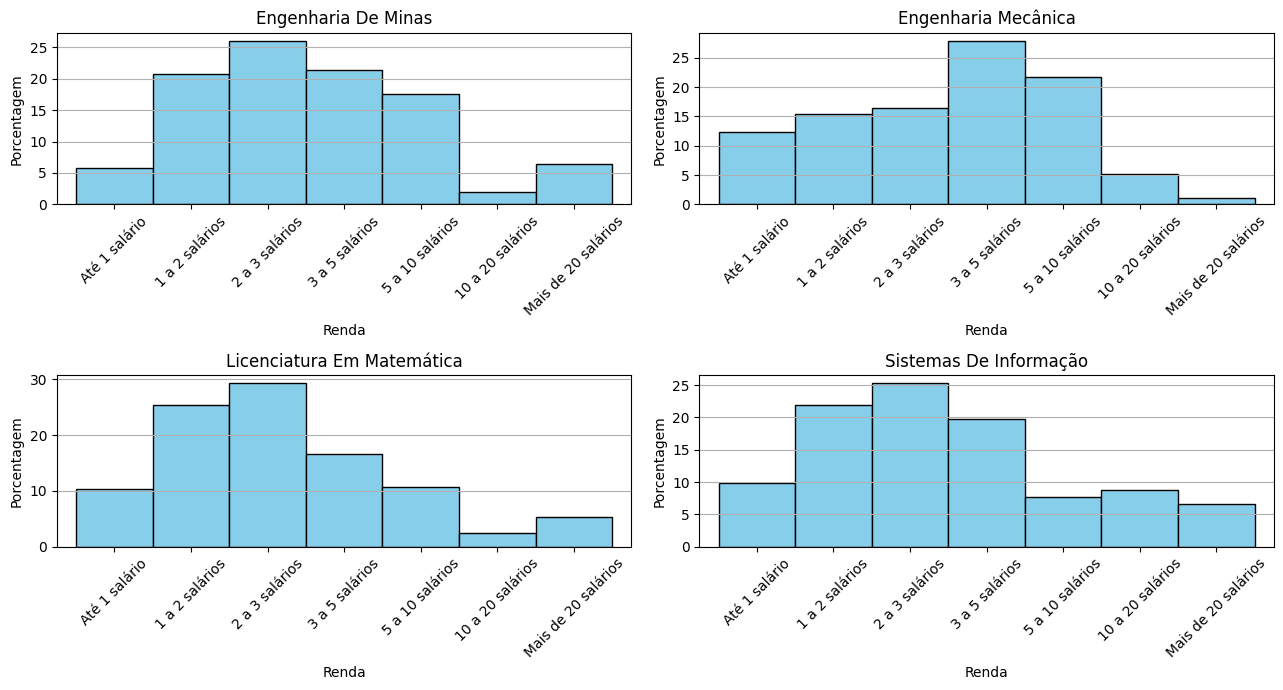

In [60]:
ordem_categorias = ["Até 1 salário", "1 a 2 salários", "2 a 3 salários", "3 a 5 salários", "5 a 10 salários", "10 a 20 salários", "Mais de 20 salários"]

# Converter a coluna 'Renda Familiar' para um tipo categórico com a ordem definida
df_evadidos['Renda Familiar'] = pd.Categorical(df_evadidos['Renda Familiar'], categories=ordem_categorias, ordered=True)


title = 'Distribuição da Renda Familiar por Curso'
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(13, 7))
for (curso, grupo), ax in zip(df_evadidos.groupby('Curso'), axes.flatten()):
    (grupo['Renda Familiar'].value_counts(normalize=True) * 100).sort_index().plot(kind='bar', color='skyblue', width=1, edgecolor='black', ax=ax)
    ax.set_title(curso)
    ax.set_xlabel('Renda')
    ax.set_ylabel('Porcentagem')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.grid(axis='y')

plt.tight_layout()
plt.savefig(f'{title}.png', dpi=300, bbox_inches='tight')
plt.show()

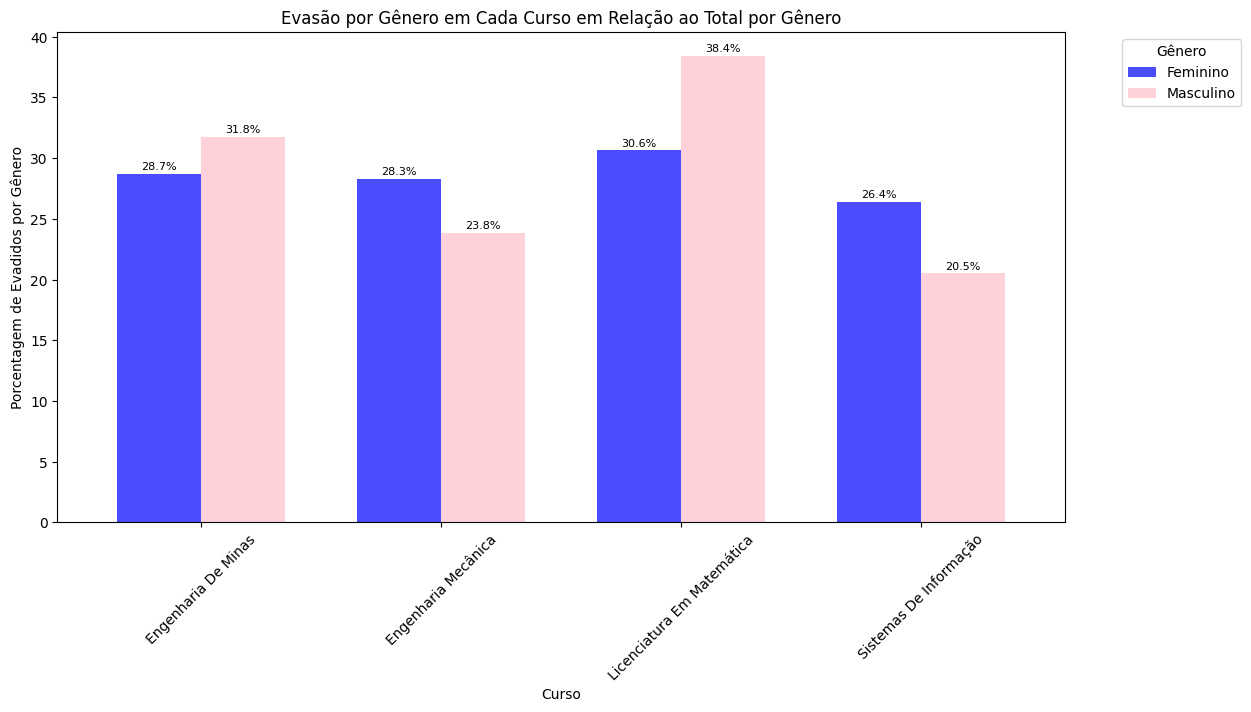

In [61]:
total_alunos_por_curso_e_sexo = df.groupby(['Curso', 'Sexo']).size().unstack(fill_value=0)

# Calcular o número total de evadidos de cada gênero em cada curso
total_evadidos_por_curso_e_sexo = df_evadidos.groupby(['Curso', 'Sexo']).size().unstack(fill_value=0)

# Calcular a porcentagem de evasão de cada gênero em relação ao total de alunos daquele gênero em cada curso
porcentagem_evadidos_por_genero_e_curso = (total_evadidos_por_curso_e_sexo.div(total_alunos_por_curso_e_sexo, axis=0) * 100)

fig, ax = plt.subplots(figsize=(13, 7))
# Plotar o gráfico de barras
ax = porcentagem_evadidos_por_genero_e_curso.plot(kind='bar', color=['blue', 'pink'], alpha=0.7, width=0.7, align='center', ax=ax)

# Adicionar rótulos nas barras
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=8, color='black', xytext=(0, 5),
                textcoords='offset points')

# Personalizar o gráfico
title = 'Evasão por Gênero em Cada Curso em Relação ao Total por Gênero'
plt.title(title)
plt.xlabel('Curso')
plt.ylabel('Porcentagem de Evadidos por Gênero')
plt.xticks(rotation=45)
plt.legend(title='Gênero', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.subplots_adjust(bottom=0.2, top=0.9) 
plt.savefig(f'{title}.png', dpi=300, bbox_inches='tight')
plt.show()

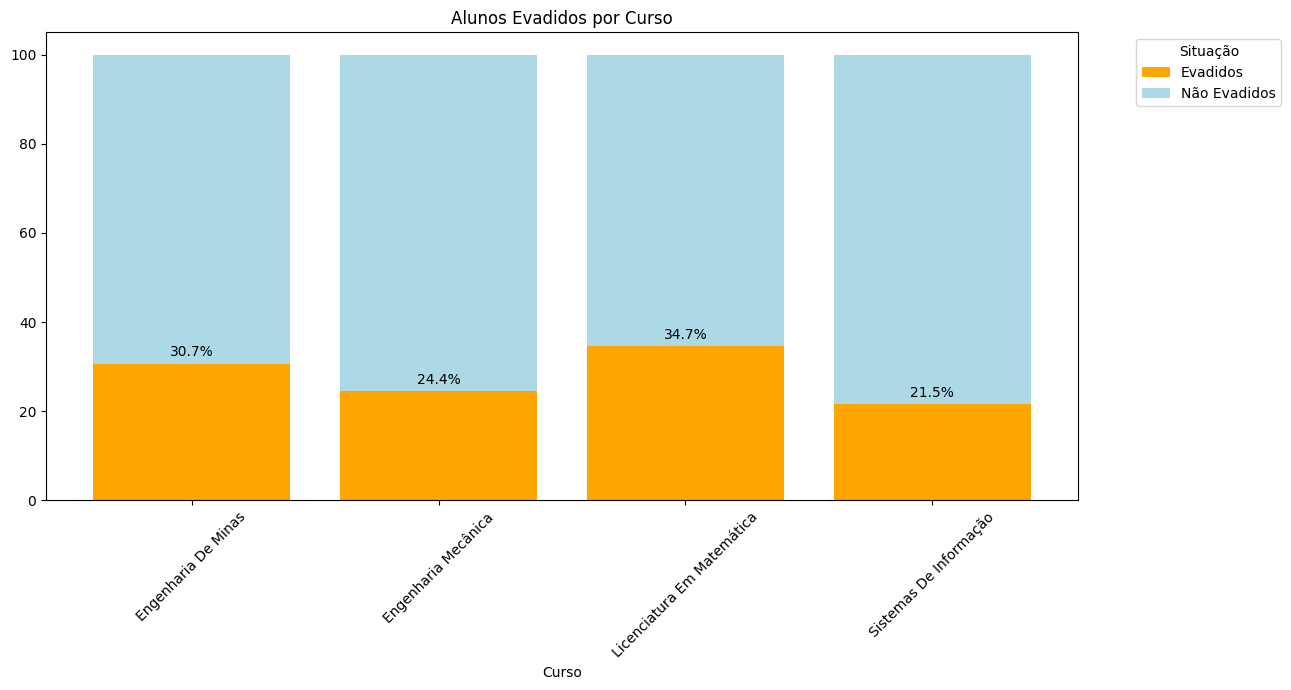

In [62]:
total_alunos_por_curso = df['Curso'].value_counts()
total_evadidos_por_curso = df_evadidos['Curso'].value_counts()
total_nao_evadidos_por_curso = total_alunos_por_curso - total_evadidos_por_curso

# Calcular as porcentagens
porcentagem_evadidos_por_curso = total_evadidos_por_curso / total_alunos_por_curso * 100

# Definindo o tamanho da figura
fig, ax = plt.subplots(figsize=(13, 7))

title = 'Alunos Evadidos por Curso'
bars = plt.bar(porcentagem_evadidos_por_curso.index, porcentagem_evadidos_por_curso, color='orange', label='Evadidos')
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 3),
                 textcoords='offset points', ha='center', va='bottom')
# Barras para alunos que não evadiram
plt.bar(total_nao_evadidos_por_curso.index, 100 - porcentagem_evadidos_por_curso, bottom=porcentagem_evadidos_por_curso, color='lightblue', label='Não Evadidos')

plt.title(title)
plt.xlabel('Curso')
plt.ylabel('')
plt.xticks(rotation=45)
plt.legend(title='Situação', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{title}.png', dpi=300, bbox_inches='tight')
plt.show()

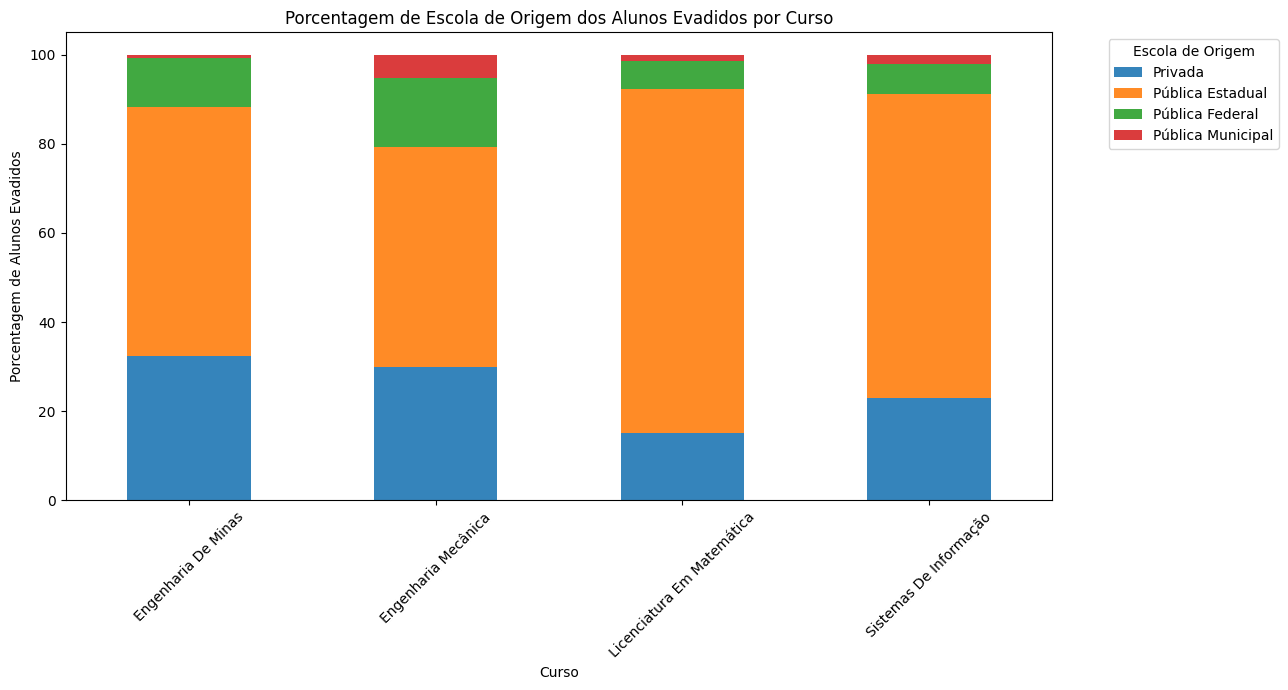

In [63]:
contagem_por_curso = df_evadidos['Escola de Origem'].value_counts()

# Calcular as porcentagens
porcentagem_por_curso = contagem_por_curso / contagem_por_curso.sum() * 100

total_evadidos_por_curso = df_evadidos['Curso'].value_counts()

# Agrupar os dados por curso e tipo de escola de origem e calcular a contagem
contagem_por_curso_e_escola = df_evadidos.groupby(['Curso', 'Escola de Origem']).size().unstack(fill_value=0)

# Calcular a porcentagem de cada tipo de escola de origem em relação ao total de alunos evadidos por curso
porcentagem_por_curso_e_escola = (contagem_por_curso_e_escola.div(total_evadidos_por_curso, axis=0) * 100)

# Plotar o gráfico de barras empilhadas
title = 'Porcentagem de Escola de Origem dos Alunos Evadidos por Curso'
porcentagem_por_curso_e_escola.plot(kind='bar', stacked=True,figsize=(13, 7), alpha=0.9)
plt.title(title)
plt.xlabel('Curso')
plt.ylabel('Porcentagem de Alunos Evadidos')
plt.xticks(rotation=45)
plt.legend(title='Escola de Origem', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{title}.png', dpi=300, bbox_inches='tight')
plt.show()

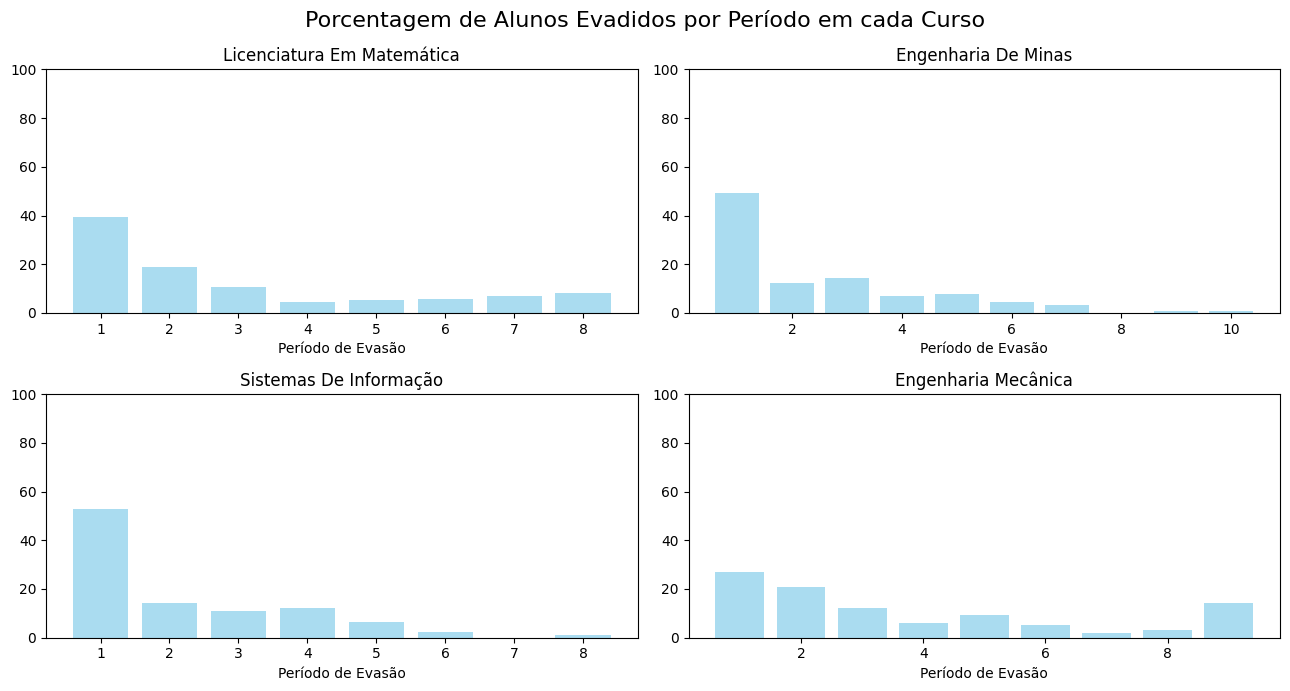

In [64]:
cursos = df_evadidos['Curso'].unique()

# Configurações do subplot
fig, axs = plt.subplots(2, 2, figsize=(13, 7))

# Plotar um gráfico para cada curso
for i, curso in enumerate(cursos):
    # Filtrar os dados para o curso atual
    df_curso = df_evadidos[df_evadidos['Curso'] == curso]
    
    # Calcular a contagem de alunos por período de evasão
    contagem_por_periodo = df_curso['Período Atual'].value_counts()
    
    # Calcular as porcentagens em relação ao total de alunos evadidos do curso
    porcentagens_por_periodo = (contagem_por_periodo / contagem_por_periodo.sum()) * 100
    
    # Plotar o gráfico de barras
    axs[i//2, i%2].bar(porcentagens_por_periodo.index, porcentagens_por_periodo, color='skyblue', alpha=0.7)
    axs[i//2, i%2].set_title(curso)
    axs[i//2, i%2].set_xlabel('Período de Evasão')
    axs[i//2, i%2].set_ylabel('')
    axs[i//2, i%2].set_ylim(0, 100)

fig.suptitle('Porcentagem de Alunos Evadidos por Período em cada Curso', fontsize=16)
plt.tight_layout()
plt.savefig('Porcentagem Alunos Evadidos.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Matheus\AppData\Local\Temp\ipykernel_11980\3217999413.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '40.625' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cancelamentos_por_curso_por_ano[curso][ano] = ((evadidos_ano / inscritos_ano) * 100)
C:\Users\Matheus\AppData\Local\Temp\ipykernel_11980\3217999413.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '78.57142857142857' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cancelamentos_por_curso_por_ano[curso][ano] = ((evadidos_ano / inscritos_ano) * 100)
C:\Users\Matheus\AppData\Local\Temp\ipykernel_11980\3217999413.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '40.625' has dtype incompatib

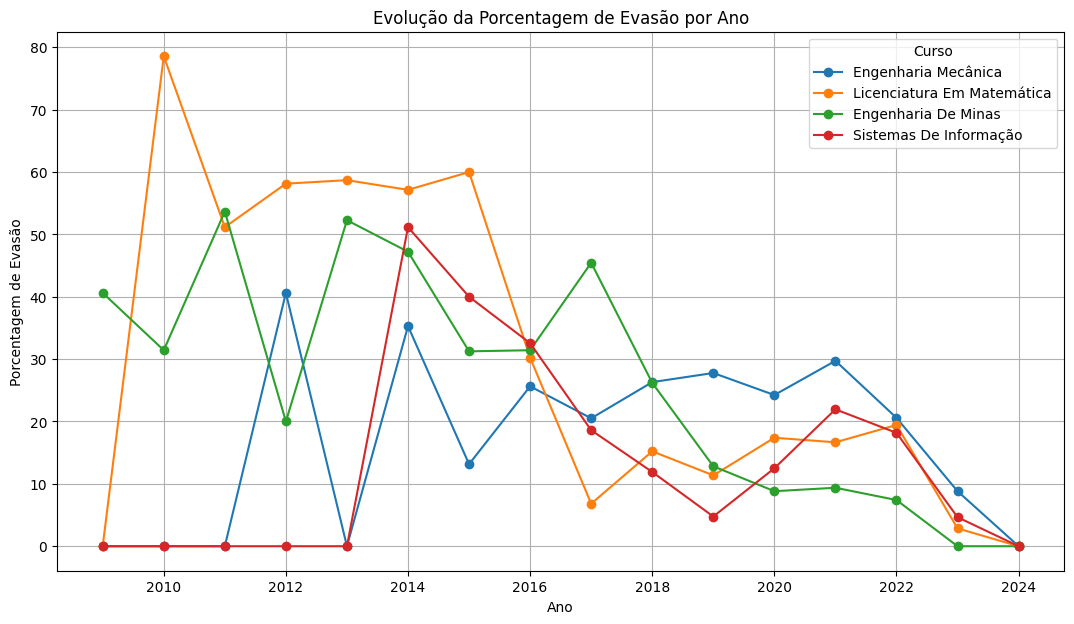

In [65]:
cursos_unicos = df['Curso'].unique()

# Inicializar o dicionário para armazenar os cancelamentos por curso por ano
cancelamentos_por_curso_por_ano = {}

# Preencher o dicionário com todos os anos possíveis e definir os valores como 0
for curso in cursos_unicos:
    cancelamentos_por_curso_por_ano[curso] = pd.Series(0, index=todos_anos)

# Contar o número de cancelamentos por ano para cada curso
for curso in cursos_unicos:
    for ano in todos_anos:
        df_curso = df[df['Curso'] == curso]
        df_evadidos_curso = df_evadidos[df_evadidos['Curso'] == curso]
        inscritos_ano = len(df_curso[df_curso['Matrícula'].str[:4].astype(int) == ano])
        evadidos_ano = len(df_evadidos_curso[df_evadidos_curso['Matrícula'].str[:4].astype(int) == ano])
        if inscritos_ano:
            cancelamentos_por_curso_por_ano[curso][ano] = ((evadidos_ano / inscritos_ano) * 100)

# Plotar
fig, ax = plt.subplots(figsize=(13, 7))
for curso, cancelamentos_por_ano in cancelamentos_por_curso_por_ano.items():
    cancelamentos_por_ano.plot(label=curso, marker='o', figsize=(13, 7))

title = 'Evolução da Porcentagem de Evasão por Ano'
plt.title(title)
plt.xlabel('Ano')
plt.ylabel('Porcentagem de Evasão')
plt.legend(title='Curso')
plt.grid(True)
plt.savefig(f'{title}.png', dpi=300)
plt.show()

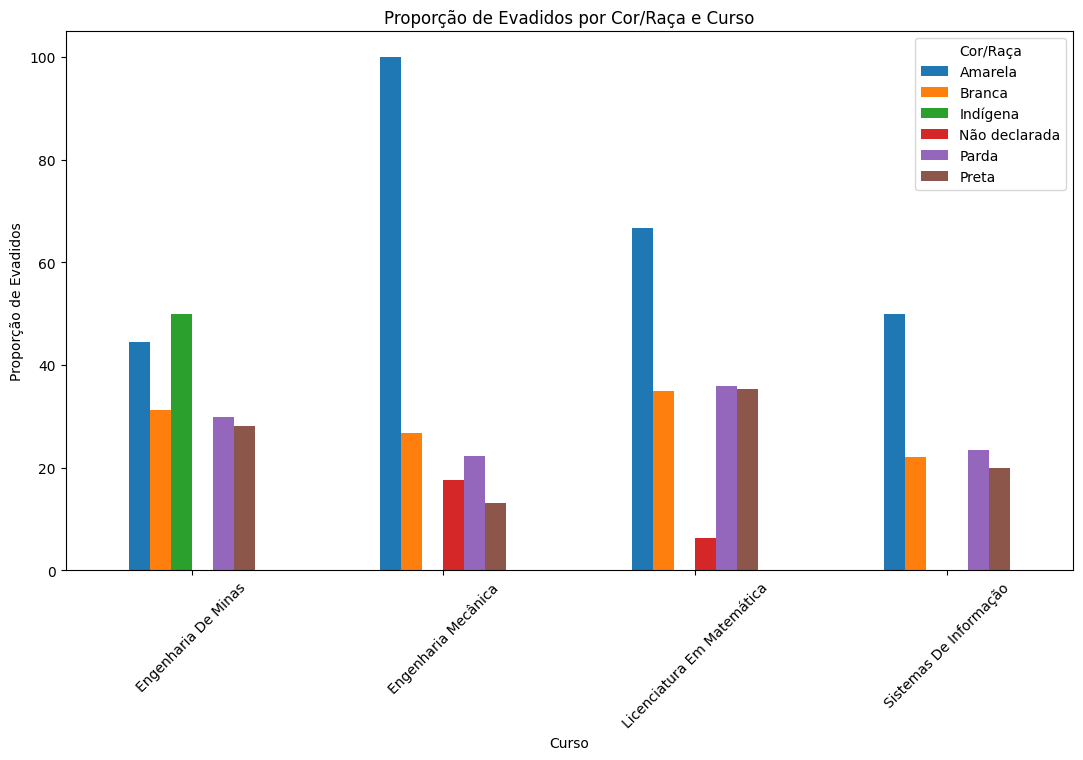

In [66]:
total_por_cor_curso = df.groupby(['Curso', 'Cor/Raça']).size()

# Calcular a contagem de pessoas evadidas por cor para cada curso
evadidos_por_cor_curso = df_evadidos.groupby(['Curso', 'Cor/Raça']).size()

# Dividir a contagem de evadidos pela contagem total para obter as proporções
proporcoes_evadidos_por_cor_curso = evadidos_por_cor_curso / total_por_cor_curso * 100

# Reorganizar os dados para plotagem
proporcoes_evadidos_por_cor_curso = proporcoes_evadidos_por_cor_curso.unstack()

# Plotar o gráfico de barras empilhadas
proporcoes_evadidos_por_cor_curso.plot(kind='bar', figsize=(13, 7))

# Adicionar rótulos e título
title = 'Proporção de Evadidos por Cor/Raça e Curso'
plt.title(title)
plt.xlabel('Curso')
plt.xticks(rotation=45)
plt.ylabel('Proporção de Evadidos')
plt.savefig(f'Proporção de Evadidos por CorRaça e Curso.png', dpi=300, bbox_inches='tight')

# Mostrar o gráfico
plt.show()

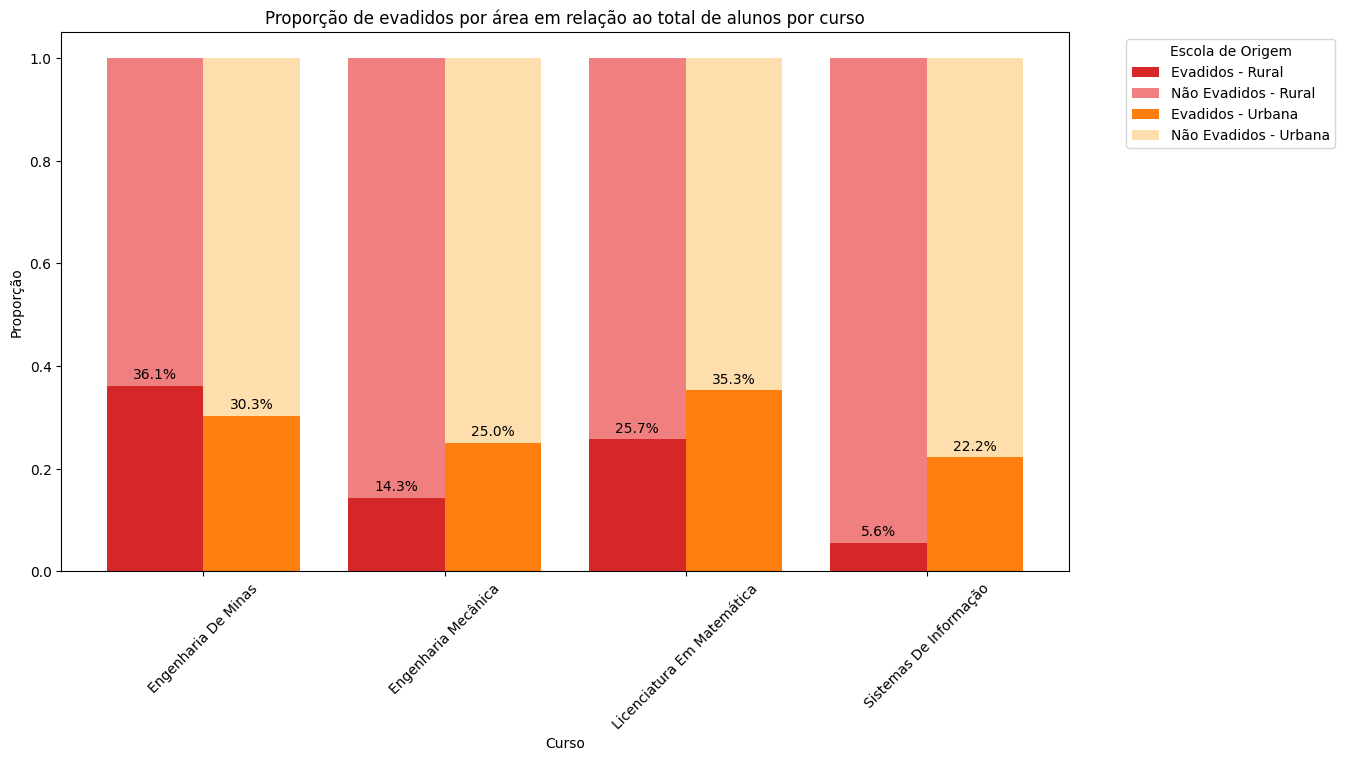

In [67]:
total_alunos = df.groupby(['Curso', 'Area Procedência Escola Origem']).size().unstack(fill_value=0)

# Calculando o total de alunos evadidos por área e curso
evadidos_por_area = df_evadidos.groupby(['Curso', 'Area Procedência Escola Origem']).size().unstack(fill_value=0)

# Calculando a proporção de alunos evadidos em relação ao total de alunos por área e curso
proporcao_evadidos = evadidos_por_area / total_alunos

# Completando com 1 - proporcao_evadidos para obter a proporção de não evadidos
proporcao_nao_evadidos = 1 - proporcao_evadidos

# Plotando o gráfico de barras lado a lado
fig, ax = plt.subplots(figsize=(13, 7))

bar_width = 0.4
index = range(len(proporcao_evadidos.index))

evadidos_bars = ax.bar(index, proporcao_evadidos['Rural'], bar_width, color='tab:red', label='Evadidos - Rural')
nao_evadidos_bars = ax.bar(index, proporcao_nao_evadidos['Rural'], bar_width, bottom=proporcao_evadidos['Rural'], color='lightcoral', label='Não Evadidos - Rural')

evadidos_bars2 = ax.bar([p + bar_width for p in index], proporcao_evadidos['Urbana'], bar_width, color='tab:orange', label='Evadidos - Urbana')
nao_evadidos_bars2 = ax.bar([p + bar_width for p in index], proporcao_nao_evadidos['Urbana'], bar_width, bottom=proporcao_evadidos['Urbana'], color='navajowhite', label='Não Evadidos - Urbana')

title = 'Proporção de evadidos por área em relação ao total de alunos por curso'
ax.set_title(title)
ax.set_xlabel('Curso')
ax.set_ylabel('Proporção')
ax.set_xticks([p + bar_width/2 for p in index])
ax.set_xticklabels(proporcao_evadidos.index)
ax.legend(title='Escola de Origem', bbox_to_anchor=(1.05, 1), loc='upper left')

def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate('{:.1f}%'.format(height * 100),
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(evadidos_bars)
autolabel(evadidos_bars2)


plt.xticks(rotation=45)
plt.savefig(f'{title}.png', dpi=300, bbox_inches='tight')
plt.show()

In [68]:
colunas = ['Sexo', 'Cor/Raça', 'Escola de Origem']

# Inicializar um dicionário para armazenar os valores absolutos e as porcentagens
dict = {}
# Iterar sobre as colunas
for curso in cursos:
    table = df_evadidos.loc[df_evadidos['Curso'] == curso]
    list = []
    for coluna in colunas:
        type = {}
        
        # Obter os valores únicos da coluna
        valores_unicos = table[coluna].unique()
        
        # Calcular os valores absolutos
        contagem_total = table[coluna].count()
        contagem_valores = table[coluna].value_counts()
        
        # Calcular as porcentagens
        porcentagens = (contagem_valores / contagem_total) * 100
        
        # Criar um dicionário com os valores
        type = {
            'N Absoluto': contagem_valores,
            '% Relativo': porcentagens
        }
        aux = pd.DataFrame(type).round(decimals=3)
        list.append(aux)
    dict[curso] = list

# Criar um DataFrame a partir do dicionário

# Exibir a tabela
print(dict.keys())
display(dict['Sistemas De Informação'])

dict_keys(['Licenciatura Em Matemática', 'Engenharia De Minas', 'Sistemas De Informação', 'Engenharia Mecânica'])


[           N Absoluto  % Relativo
 Sexo                             
 Masculino          72      79.121
 Feminino           19      20.879,
           N Absoluto  % Relativo
 Cor/Raça                        
 Branca            50      54.945
 Parda             32      35.165
 Preta              7       7.692
 Amarela            2       2.198,
                    N Absoluto  % Relativo
 Escola de Origem                         
 Pública Estadual           62      68.132
 Privada                    21      23.077
 Pública Federal             6       6.593
 Pública Municipal           2       2.198]

GRÁFICO DAS CIDADES
GRAFICO COR/RAÇA
GRAFICO COTA